# What is the most optimal skill to learn for Data Analysts?

#### Methodology

1. Continue from last notebook to find percent of postings with skill
2. Visualize median salary vs percent skill demand
3. (Optional) Determine if certain technologies are more prevalent

In [34]:

import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data cleanup 
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
# Converting job_skills column to list
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)





## Clean Data

Filters the original dataset to only get rows where the job title is 'Data Analyst' and the country is 'United States', to create a new DataFrame `df_DA_US`. Drop NaN values from the 'salary_year_avg' column. Then it uses the `explode` method on the `job_skills` column to create a new row in a new DataFrame (`df_DA_US_exploded`) for each skill associated with a job. 

In [35]:
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

# Drop NaN values from the 'salary_year_avg' column for accurate visualization
df_DA = df_DA_US.dropna(subset=['salary_year_avg'])

df_DA_exploded = df_DA_US.explode('job_skills')

df_DA_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


## Calculate Percent of Job Postings that Have Skills

Group the data by job skills and calculates the count and median salary for each skill, sorting the results in descending order by count. It then renames the columns. Calculates the percentage that each skill count represents out of the total number of Data Analyst jobs. Finally, filter out any skills that don't have any jobs associated with them.

In [36]:
df_DA_skills = df_DA_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

DA_job_count = len(df_DA_US)  

df_DA_skills['skill_percent'] = ((df_DA_skills['skill_count'] / DA_job_count) * 100).round(2)

df_DA_skills = df_DA_skills[df_DA_skills['skill_count'] > 0]

df_DA_skills

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.0,57.66
excel,1808,84392.0,41.56
python,1431,97500.0,32.90
tableau,1364,92875.0,31.36
sas,926,90000.0,21.29
...,...,...,...
theano,1,100000.0,0.02
typescript,1,65000.0,0.02
vmware,1,147500.0,0.02


## Median Salary vs Percent Skill Demand

Filters for Data Analyst skills that exceed a 5%



In [37]:
df_DA_skills_filter = df_DA_skills[df_DA_skills['skill_percent'] > 5]

df_DA_skills_filter

,skill_count,median_salary,skill_percent
job_skills,,,
sql,2508,91000.00,57.66
excel,1808,84392.00,41.56
python,1431,97500.00,32.90
tableau,1364,92875.00,31.36
sas,926,90000.00,21.29
r,893,92500.00,20.53
power bi,838,90000.00,19.26
powerpoint,462,85000.00,10.62
word,461,81194.75,10.60


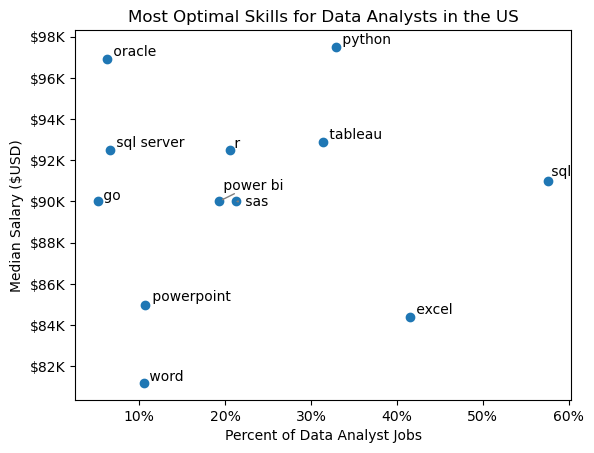

In [38]:

plt.scatter(df_DA_skills_filter['skill_percent'], df_DA_skills_filter['median_salary'])
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary ($USD)')  # Assuming this is the label you want for y-axis
plt.title('Most Optimal Skills for Data Analysts in the US')


from matplotlib.ticker import PercentFormatter
from adjustText import adjust_text

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))  
ax.xaxis.set_major_formatter(PercentFormatter(decimals = 0))

# Add labels to points and collect them in a list
texts = []
for i, txt in enumerate(df_DA_skills_filter.index):
    texts.append(
        plt.text(df_DA_skills_filter['skill_percent'].iloc[i], 
        df_DA_skills_filter['median_salary'].iloc[i], 
        " " + txt))

# Adjust text to avoid overlap and add arrows
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.show()

# Coloring by Technology

We're going to add color labels based on technology.

Removes duplicate entries and any rows with missing values. Then, it combines all dictionary entries into a single dictionary, summing values for keys that repeat across entries. To ensure each key's values are unique, it converts the values to a set and then back to a list. 
- The final result is a dictionary where each key represents a skill and each value is a list of unique attributes associated with that skill.

In [ ]:
df_technology = df['job_type_skills'].copy()

df_technology = df_technology.drop_duplicates()

df_technology = df_technology.dropna()


In [40]:
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)
    for key,value in row_dict.items():
        if key in technology_dict:
            technology_dict[key] += value
        else:
            technology_dict[key] =  value

for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict    

{'analyst_tools': ['power bi',
  'ms access',
  'ssrs',
  'splunk',
  'sheets',
  'ssis',
  'esquisse',
  'visio',
  'cognos',
  'alteryx',
  'msaccess',
  'outlook',
  'datarobot',
  'powerpoint',
  'spss',
  'looker',
  'nuix',
  'powerbi',
  'sap',
  'excel',
  'dax',
  'microstrategy',
  'spreadsheet',
  'word',
  'tableau',
  'qlik',
  'sas',
  'sharepoint'],
 'programming': ['rust',
  'c#',
  'erlang',
  'bash',
  'javascript',
  'go',
  'ocaml',
  'assembly',
  'sql',
  'groovy',
  'css',
  'visualbasic',
  'haskell',
  'fortran',
  'scala',
  'f#',
  'r',
  'python',
  'apl',
  'no-sql',
  'visual basic',
  'lisp',
  'lua',
  'mongodb',
  'java',
  'typescript',
  'matlab',
  'vb.net',
  'shell',
  'delphi',
  'elixir',
  'nosql',
  'solidity',
  'crystal',
  'php',
  'sass',
  'kotlin',
  'dart',
  'clojure',
  'swift',
  'vba',
  'objective-c',
  'golang',
  'cobol',
  'c++',
  't-sql',
  'c',
  'ruby',
  'html',
  'powershell',
  'mongo',
  'julia',
  'sas',
  'pascal',
  'p

In [41]:
# turn dictionary into dataframe
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology


,technology,skills
0,analyst_tools,power bi
0,analyst_tools,ms access
0,analyst_tools,ssrs
0,analyst_tools,splunk
0,analyst_tools,sheets
...,...,...
9,sync,webex
9,sync,ringcentral
9,sync,symphony
9,sync,microsoft teams


Merges two DataFrames, df_DA_skills_filter and df_technology, based on the columns 'job_skills' and 'skills' respectively, creating a new DataFrame df_DA_skills_tech.

In [42]:
df_DA_skills_tech = df_DA_skills_filter.merge(df_technology, left_on='job_skills', right_on='skills')

df_DA_skills_tech

,skill_count,median_salary,skill_percent,technology,skills
0,2508,91000.00,57.66,programming,sql
1,1808,84392.00,41.56,analyst_tools,excel
2,1431,97500.00,32.90,programming,python
3,1364,92875.00,31.36,analyst_tools,tableau
4,926,90000.00,21.29,analyst_tools,sas
5,926,90000.00,21.29,programming,sas
6,893,92500.00,20.53,programming,r
7,838,90000.00,19.26,analyst_tools,power bi
8,462,85000.00,10.62,analyst_tools,powerpoint
9,461,81194.75,10.60,analyst_tools,word


Plot the results in a scatter plot, coloring the points based on the 'technology' column.

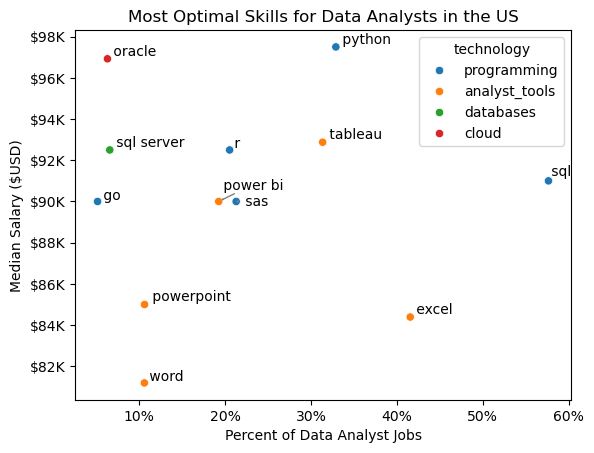

In [48]:

sns.scatterplot(
    data = df_DA_skills_tech,
    x = 'skill_percent',
    y = 'median_salary',
    hue = 'technology'
)
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary ($USD)')  # Assuming this is the label you want for y-axis
plt.title('Most Optimal Skills for Data Analysts in the US')


from matplotlib.ticker import PercentFormatter
from adjustText import adjust_text

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))  
ax.xaxis.set_major_formatter(PercentFormatter(decimals = 0))

# Add labels to points and collect them in a list
texts = []
for i, txt in enumerate(df_DA_skills_filter.index):
    texts.append(
        plt.text(df_DA_skills_filter['skill_percent'].iloc[i], 
        df_DA_skills_filter['median_salary'].iloc[i], 
        " " + txt))

# Adjust text to avoid overlap and add arrows
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.show()

[Text(58.873499747983864, 91436.74776785713, ' sql'),
 Text(44.158371597782256, 84731.69270833331, ' excel'),
 Text(36.21892842741935, 97839.69270833331, ' python'),
 Text(34.919114037298385, 93214.69270833331, ' tableau'),
 Text(23.458948840725803, 89999.99999999999, ' sas'),
 Text(21.178501146673387, 92791.16517857142, ' r'),
 Text(23.01562953629032, 90776.44047619046, ' power bi'),
 Text(15.794908140120967, 85388.22023809522, ' powerpoint'),
 Text(12.965464339717741, 81485.9151785714, ' word'),
 Text(11.024351310483869, 92839.69270833331, ' sql server'),
 Text(9.284124243951613, 97263.44270833333, ' oracle'),
 Text(6.532886844758064, 90291.16517857142, ' go')]